# Проект по ML (6 семестр)

## Предсказание результата забега в Umamusume: Pretty Derby

Кубякин, Аникин

### Загрузка библиотек

In [23]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn

### Датасет

In [24]:
data = pd.read_excel('Umamusume ML.xlsx')
data.head(15)

,score,letter,SPD,STA,PWR,GUTS,WIT,ult_lvl,inherited_ult,G1_wins,...,green_skills,skills_sprint,skills_mile,skills_medium,skills_long,skills_front,skills_pace,skills_late,skills_end,skills_universal
0,19699,Ug,1200,935,1167,989,799,4,-,18,...,6.0,1.0,0.0,0.0,0.0,0.0,6.0,0.0,0,9
1,19684,Ug,1196,910,1179,504,1110,5,seiun,17,...,7.0,0.0,0.0,0.0,0.0,7.0,0.0,0.0,0,8
2,21721,Ug,1200,774,1200,758,1200,6,opera_skin,23,...,4.0,0.0,4.0,0.0,0.0,0.0,8.0,0.0,0,11
3,20520,Ug,1200,883,1200,646,1187,5,opera_skin. seiun,18,...,1.0,0.0,0.0,3.0,0.0,5.0,0.0,0.0,0,9
4,20958,Ug,1200,699,1177,695,1200,6,dober,20,...,3.0,0.0,5.0,0.0,0.0,0.0,0.0,6.0,0,10
5,19460,SS+,1046,1046,1184,749,830,5,-,18,...,3.0,0.0,5.5,0.0,0.0,0.0,0.0,5.5,0,4
6,19505,SS+,1200,574,1200,601,1200,6,dober,16,...,1.0,2.0,0.0,0.0,0.0,0.0,0.0,7.0,0,10
7,19245,SS+,1200,1014,966,795,856,5,seiun,20,...,5.0,0.0,0.0,6.0,0.0,5.0,0.0,0.0,0,6
8,19474,SS+,1200,1140,957,653,1057,5,kitasan,20,...,2.0,0.0,0.0,0.0,4.0,4.0,0.0,0.0,0,8
9,19587,SS+,1198,851,1026,951,935,5,-,23,...,3.0,0.0,5.0,0.0,0.0,0.0,6.0,0.0,0,10


### Подготовка и препроцессинг

In [25]:
letters = set(data['letter'].tolist())
letters_count = []
for letter in letters:
    letters_count.append([letter, 0])
indexes_for_mask = []
letters_count = []

In [26]:
for index, row in data.iterrows():
    current_letter = row['letter']
    if letters_count.count(current_letter) >= 2:
        continue
    else:
        letters_count.append(current_letter)
        indexes_for_mask.append(index)
    '''for e in letters_count:
        if current_letter == e[0]:
            current_count = e[1]
        else:
            continue
    if current_count < 2:
        indexes_for_mask.append(index)
        '''

In [27]:
mask = np.zeros(data.shape[0], dtype=int)
for i in indexes_for_mask:
    mask[i] = 1
mask = mask.astype(bool)

In [28]:
def ultifier(string):
    if string == '-':
        to_return = 0
    else:
        words = [w.strip() for w in str(string).split('.') if w.strip()]
        to_return = len(words)
    return to_return

In [29]:
apt_map = {
    "S": 8,
    "A": 7,
    "B": 6,
    "C": 5,
    "D": 4,
    "E": 3,
    "F": 2,
    "G": 1,
}
aptitudes = []
for col in data.columns:
    if 'apt' in col:
        aptitudes.append(col)
for apt in aptitudes:
    data[apt] = data[apt].map(apt_map)

In [30]:
udata = data.copy()

In [31]:
udata['inherited_ult'] = data['inherited_ult'].copy().apply(ultifier)

In [32]:
#udata_with_letter = udata.copy()
udata.drop('letter', axis=1, inplace=True)
#udata.drop('Fans', axis=1, inplace=True)

In [33]:
udata.head(15)

,score,SPD,STA,PWR,GUTS,WIT,ult_lvl,inherited_ult,G1_wins,G1_prize,...,green_skills,skills_sprint,skills_mile,skills_medium,skills_long,skills_front,skills_pace,skills_late,skills_end,skills_universal
0,19699,1200,935,1167,989,799,4,0,18,0,...,6.0,1.0,0.0,0.0,0.0,0.0,6.0,0.0,0,9
1,19684,1196,910,1179,504,1110,5,1,17,0,...,7.0,0.0,0.0,0.0,0.0,7.0,0.0,0.0,0,8
2,21721,1200,774,1200,758,1200,6,1,23,0,...,4.0,0.0,4.0,0.0,0.0,0.0,8.0,0.0,0,11
3,20520,1200,883,1200,646,1187,5,2,18,0,...,1.0,0.0,0.0,3.0,0.0,5.0,0.0,0.0,0,9
4,20958,1200,699,1177,695,1200,6,1,20,0,...,3.0,0.0,5.0,0.0,0.0,0.0,0.0,6.0,0,10
5,19460,1046,1046,1184,749,830,5,0,18,0,...,3.0,0.0,5.5,0.0,0.0,0.0,0.0,5.5,0,4
6,19505,1200,574,1200,601,1200,6,1,16,0,...,1.0,2.0,0.0,0.0,0.0,0.0,0.0,7.0,0,10
7,19245,1200,1014,966,795,856,5,1,20,0,...,5.0,0.0,0.0,6.0,0.0,5.0,0.0,0.0,0,6
8,19474,1200,1140,957,653,1057,5,1,20,0,...,2.0,0.0,0.0,0.0,4.0,4.0,0.0,0.0,0,8
9,19587,1198,851,1026,951,935,5,0,23,0,...,3.0,0.0,5.0,0.0,0.0,0.0,6.0,0.0,0,10


### Корреляционная матрица

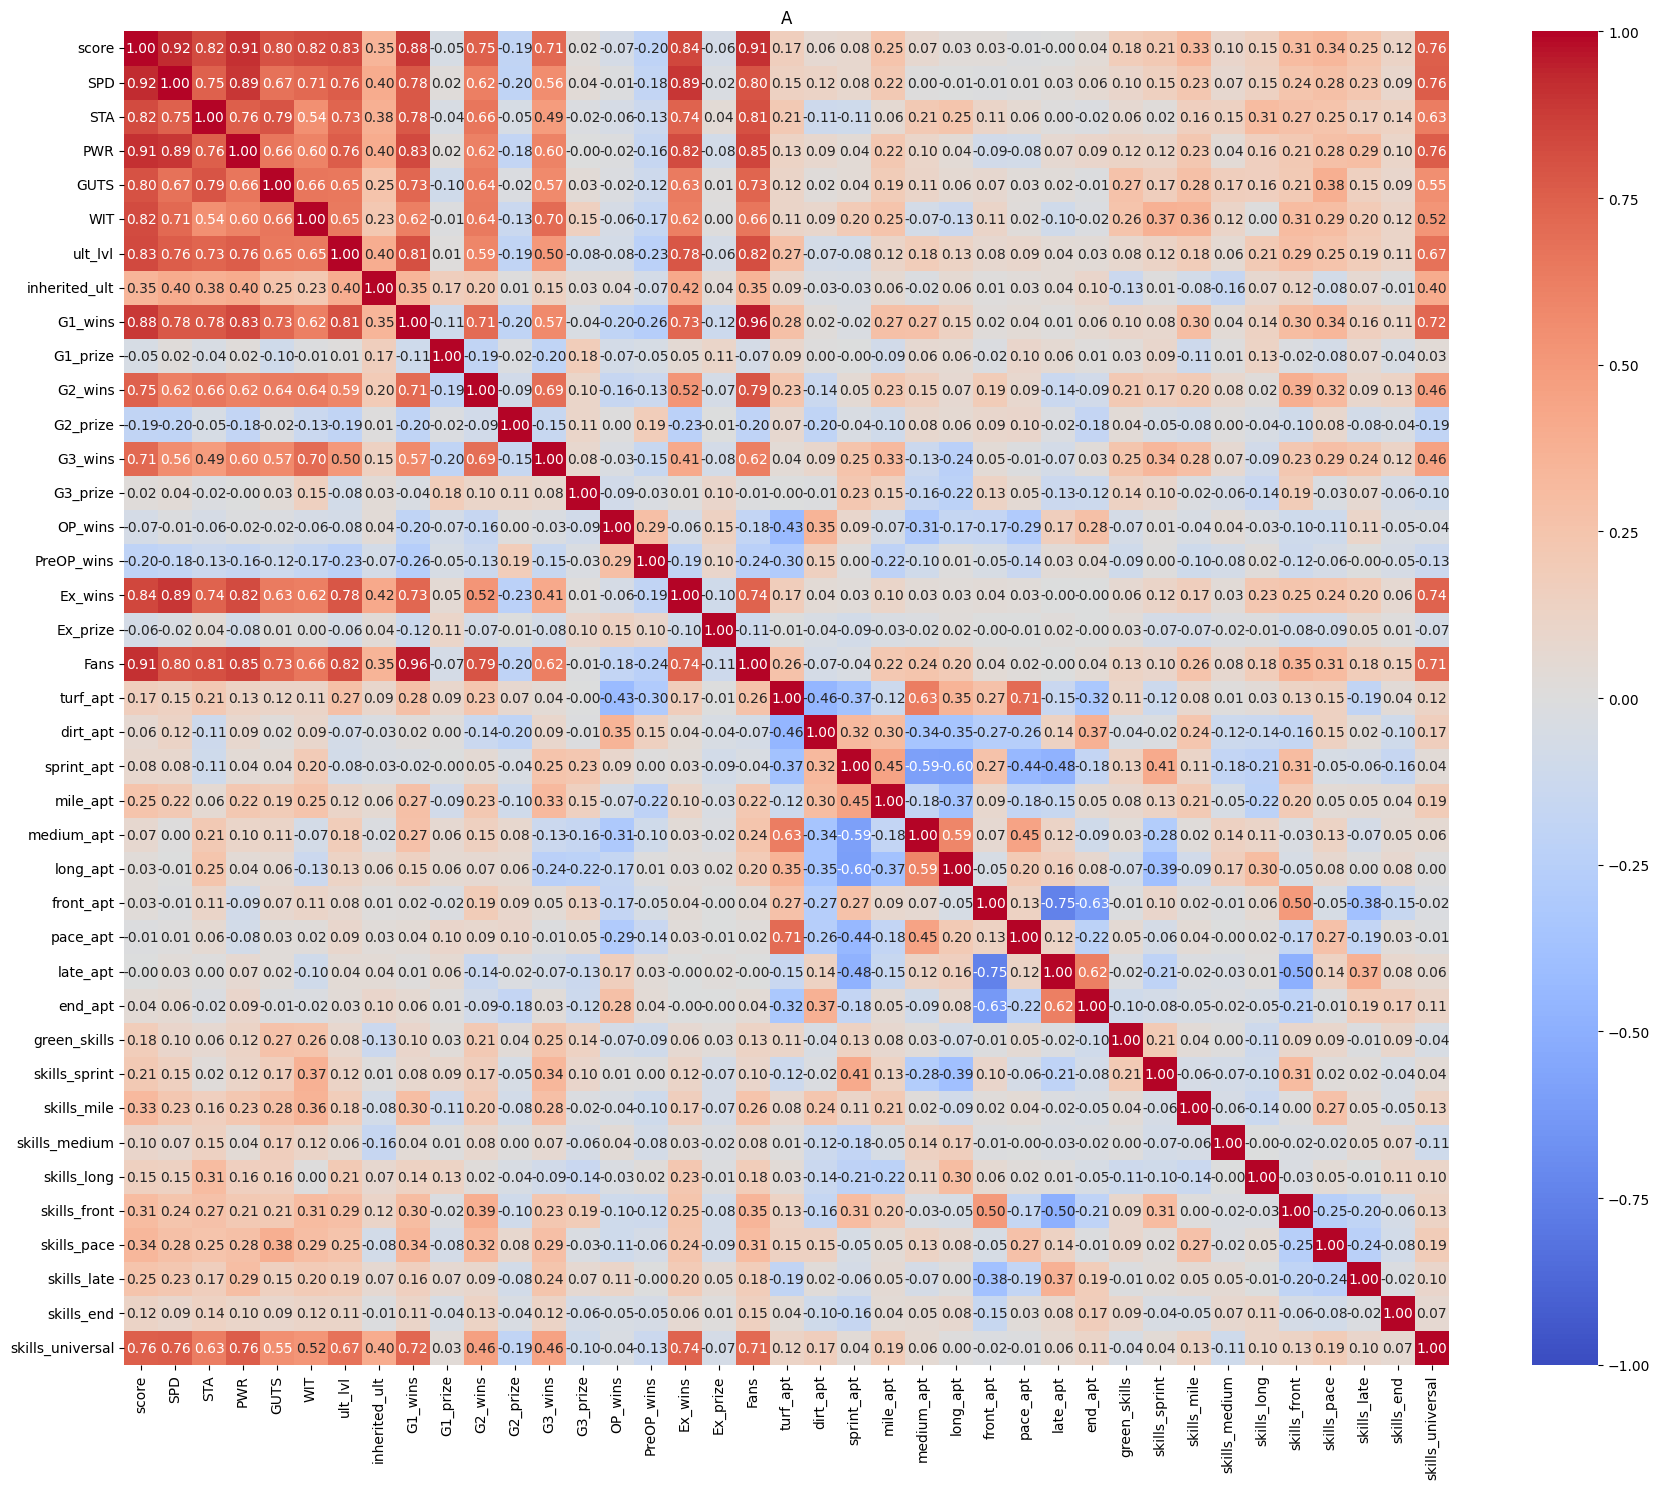

In [34]:
corr_matrix = udata.corr()
plt.figure(figsize=(18, 15))

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title('A')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

### Разбиение на train и test

In [35]:
train_df = udata[~mask]
test_df = udata[mask]

test_df

,score,SPD,STA,PWR,GUTS,WIT,ult_lvl,inherited_ult,G1_wins,G1_prize,...,green_skills,skills_sprint,skills_mile,skills_medium,skills_long,skills_front,skills_pace,skills_late,skills_end,skills_universal
0,19699,1200,935,1167,989,799,4,0,18,0,...,6.0,1.0,0.0,0.0,0.0,0.0,6.0,0.0,0,9
1,19684,1196,910,1179,504,1110,5,1,17,0,...,7.0,0.0,0.0,0.0,0.0,7.0,0.0,0.0,0,8
5,19460,1046,1046,1184,749,830,5,0,18,0,...,3.0,0.0,5.5,0.0,0.0,0.0,0.0,5.5,0,4
6,19505,1200,574,1200,601,1200,6,1,16,0,...,1.0,2.0,0.0,0.0,0.0,0.0,0.0,7.0,0,10
10,18325,1200,734,1054,432,1200,4,1,18,0,...,0.0,0.0,7.0,0.0,0.0,6.0,0.0,0.0,0,5
11,17681,1200,827,1087,532,1098,5,1,15,1,...,0.0,5.0,0.0,0.0,0.0,8.0,0.0,0.0,0,5
17,16327,1200,811,656,560,1137,4,1,16,4,...,3.0,0.0,0.0,4.5,0.0,0.0,0.0,6.0,0,5
18,16184,1200,812,1200,428,564,4,2,16,0,...,1.0,0.0,0.0,0.0,1.0,0.0,2.0,2.0,0,10
27,15446,1196,849,1161,519,592,5,2,19,0,...,1.5,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0,9
28,14854,1200,760,1200,489,452,4,1,20,0,...,1.5,1.0,0.0,0.0,0.0,5.0,0.0,0.0,0,7


### Проверка на пропуски

In [36]:
print('Все колонки:')
print(udata.columns.tolist())
print('\nФорма:', udata.shape)
print('\nПропуски:')
print(udata.isnull().sum())

Все колонки:
['score', 'SPD', 'STA', 'PWR', 'GUTS', 'WIT', 'ult_lvl', 'inherited_ult', 'G1_wins', 'G1_prize', 'G2_wins', 'G2_prize', 'G3_wins', 'G3_prize', 'OP_wins', 'PreOP_wins', 'Ex_wins', 'Ex_prize', 'Fans', 'turf_apt', 'dirt_apt', 'sprint_apt', 'mile_apt', 'medium_apt', 'long_apt', 'front_apt', 'pace_apt', 'late_apt', 'end_apt', 'green_skills', 'skills_sprint', 'skills_mile', 'skills_medium', 'skills_long', 'skills_front', 'skills_pace', 'skills_late', 'skills_end', 'skills_universal']

Форма: (200, 39)

Пропуски:
score               0
SPD                 0
STA                 0
PWR                 0
GUTS                0
WIT                 0
ult_lvl             0
inherited_ult       0
G1_wins             0
G1_prize            0
G2_wins             0
G2_prize            0
G3_wins             0
G3_prize            0
OP_wins             0
PreOP_wins          0
Ex_wins             0
Ex_prize            0
Fans                0
turf_apt            0
dirt_apt            0
sprint_apt   

### Таргет и размеры train/test

In [37]:
TARGET = "score" 
print('Таргет:', TARGET)

X_train = train_df.drop(columns=[TARGET])
y_train = train_df[TARGET]

X_test = test_df.drop(columns=[TARGET])
y_test = test_df[TARGET]

'''
y_train = np.log1p(y_train)
y_test  = np.log1p(y_test)

print('Логарифмирование таргета: np.log1p')'''

print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Таргет: score
Train: (172, 38), Test: (28, 38)


### Imputer и Scaler

In [38]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Импутация пропусков + масштабирование
preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

### Сравнение моделей (кросс-валидация на train)

In [39]:
import numpy as np
import pandas as pd
import warnings

from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor
)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error


warnings.filterwarnings('ignore')

# Модели

models = {

    'Ridge': Ridge(alpha=10),

    'Lasso': Lasso(
        alpha=0.1,
        max_iter=10000
    ),

    'ElasticNet': ElasticNet(
        alpha=0.1,
        l1_ratio=0.5,
        max_iter=10000
    ),

    'Polynomial (deg=2)': Pipeline([
        ('scaler', StandardScaler()),
        ('poly', PolynomialFeatures(
            degree=2,
            include_bias=False
        )),
        ('model', LinearRegression())
    ]),

    'SVR (RBF)': Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVR(
            kernel='rbf',
            C=30,
            epsilon=0.05
        ))
    ]),

    'SVR (Linear)': Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVR(
            kernel='linear',
            C=1.0
        ))
    ]),

    'KNN': Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsRegressor(
            n_neighbors=5,
            weights='distance'
        ))
    ]),

    'Random Forest': RandomForestRegressor(
        n_estimators=500,
        max_depth=8,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ),

    'Extra Trees': ExtraTreesRegressor(
        n_estimators=500,
        max_depth=8,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ),

    'Gradient Boost': GradientBoostingRegressor(
        n_estimators=500,
        max_depth=5,
        learning_rate=0.03,
        subsample=0.8,
        random_state=42
    ),
}


# CV
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
results = []

# Оценка

for name, model in models.items():

    r2_scores = []
    mae_scores = []

    for train_idx, valid_idx in cv.split(X_train_proc):

        X_tr = X_train_proc[train_idx]
        X_val = X_train_proc[valid_idx]

        y_tr = y_train.iloc[train_idx]
        y_val = y_train.iloc[valid_idx]

        model.fit(X_tr, y_tr)

        preds = model.predict(X_val)

        #preds = np.expm1(preds_log)
        #y_val = np.expm1(y_val_log)

        r2_scores.append(
            r2_score(y_val, preds)
        )

        mae_scores.append(
            mean_absolute_error(y_val, preds)
        )

    results.append({
        'Модель': name,
        'R² (mean)': round(np.mean(r2_scores), 4),
        'R² (std)': round(np.std(r2_scores), 4),
        'MAE (mean)': round(np.mean(mae_scores), 4),
        'MAE (std)': round(np.std(mae_scores), 4),
    })

    print(
        f'{name:<35} '
        f'R²={np.mean(r2_scores):.4f} ± {np.std(r2_scores):.4f}   '
        f'MAE={np.mean(mae_scores):.4f} ± {np.std(mae_scores):.4f}'
    )

# Результаты

results_df = pd.DataFrame(results).sort_values(
    'R² (mean)',
    ascending=False
)

print('\n--- Итог (по R²) ---')
print(results_df.to_string(index=False))

Ridge                               R²=0.9858 ± 0.0040   MAE=467.2791 ± 54.5701
Lasso                               R²=0.9859 ± 0.0054   MAE=470.2166 ± 88.2351
ElasticNet                          R²=0.9862 ± 0.0041   MAE=460.6833 ± 56.1850
Polynomial (deg=2)                  R²=0.9271 ± 0.0206   MAE=1018.4578 ± 180.8373
SVR (RBF)                           R²=0.0651 ± 0.0213   MAE=4089.0522 ± 251.7842
SVR (Linear)                        R²=0.3275 ± 0.0270   MAE=3490.1917 ± 218.8476
KNN                                 R²=0.8848 ± 0.0173   MAE=1294.3359 ± 104.2118
Random Forest                       R²=0.9575 ± 0.0161   MAE=741.5377 ± 134.4030
Extra Trees                         R²=0.9670 ± 0.0141   MAE=658.3051 ± 130.6058
Gradient Boost                      R²=0.9658 ± 0.0148   MAE=663.2113 ± 149.8513

--- Итог (по R²) ---
            Модель  R² (mean)  R² (std)  MAE (mean)  MAE (std)
        ElasticNet     0.9862    0.0041    460.6833    56.1850
             Lasso     0.9859    0.0054  

### Сохранение модели

In [40]:
import joblib
import os
import json
from datetime import datetime
from sklearn.base import clone

# Лучшая модель

best_row = results_df.iloc[0]

best_model_name = best_row['Модель']
best_model = clone(models[best_model_name])

print(f'Best model: {best_model_name}')

best_model.fit(X_train_proc, y_train)

y_pred_test = best_model.predict(X_test_proc)

'''# back to original scale
y_pred_test = np.expm1(y_pred_test_log)

# original y values
y_test = np.expm1(y_test)'''

test_r2 = r2_score(y_test, y_pred_test)
test_mae = mean_absolute_error(y_test, y_pred_test)

print(f'Test R² : {test_r2:.4f}')
print(f'Test MAE: {test_mae:.4f}')

# Сохранение

timestamp = datetime.now().strftime('%Y%m%d_%H%M')

safe_name = (
    best_model_name
    .lower()
    .replace(' ', '_')
    .replace('(', '')
    .replace(')', '')
    .replace('=', '')
)

model_path        = f'best_{safe_name}_{timestamp}.joblib'
preprocessor_path = f'preprocessor_{timestamp}.joblib'
meta_path         = f'model_meta_{timestamp}.json'

joblib.dump(best_model, model_path)

joblib.dump(preprocessor, preprocessor_path)

# Параметры

params = best_model.get_params()
serializable_params = {}

for k, v in params.items():
    try:
        json.dumps(v)
        serializable_params[k] = v
    except:
        serializable_params[k] = str(v)

meta = {
    'feature_names': list(X_train.columns),
    'target': 'score',
    'model': best_model_name,
    'params': serializable_params,
    'cv_r2_mean': round(float(best_row['R² (mean)']), 4),
    'cv_mae_mean': round(float(best_row['MAE (mean)']), 4),
    'test_r2': round(float(test_r2), 4),
    'test_mae': round(float(test_mae), 4),
    'timestamp': timestamp,
}

with open(meta_path, 'w') as f:
    json.dump(meta, f, indent=2)

print(f"\nSaved:")
print(f"  Model : {model_path} ({os.path.getsize(model_path)/1024:.1f} KB)")
print(f"  Meta  : {meta_path}")

# Проверка

_loaded_model = joblib.load(model_path)
_check_preds = _loaded_model.predict(X_test_proc)

# convert back
#_check_preds = np.expm1(_check_preds_log)

_match = np.allclose(_check_preds, y_pred_test)

print(
    f"\nReload check: "
    f"{'predictions match' if _match else 'mismatch — do not use'}"
)

Best model: ElasticNet
Test R² : 0.9898
Test MAE: 458.9685

Saved:
  Model : best_elasticnet_20260522_2209.joblib (0.9 KB)
  Meta  : model_meta_20260522_2209.json

Reload check: predictions match


### Визуализация сравнения

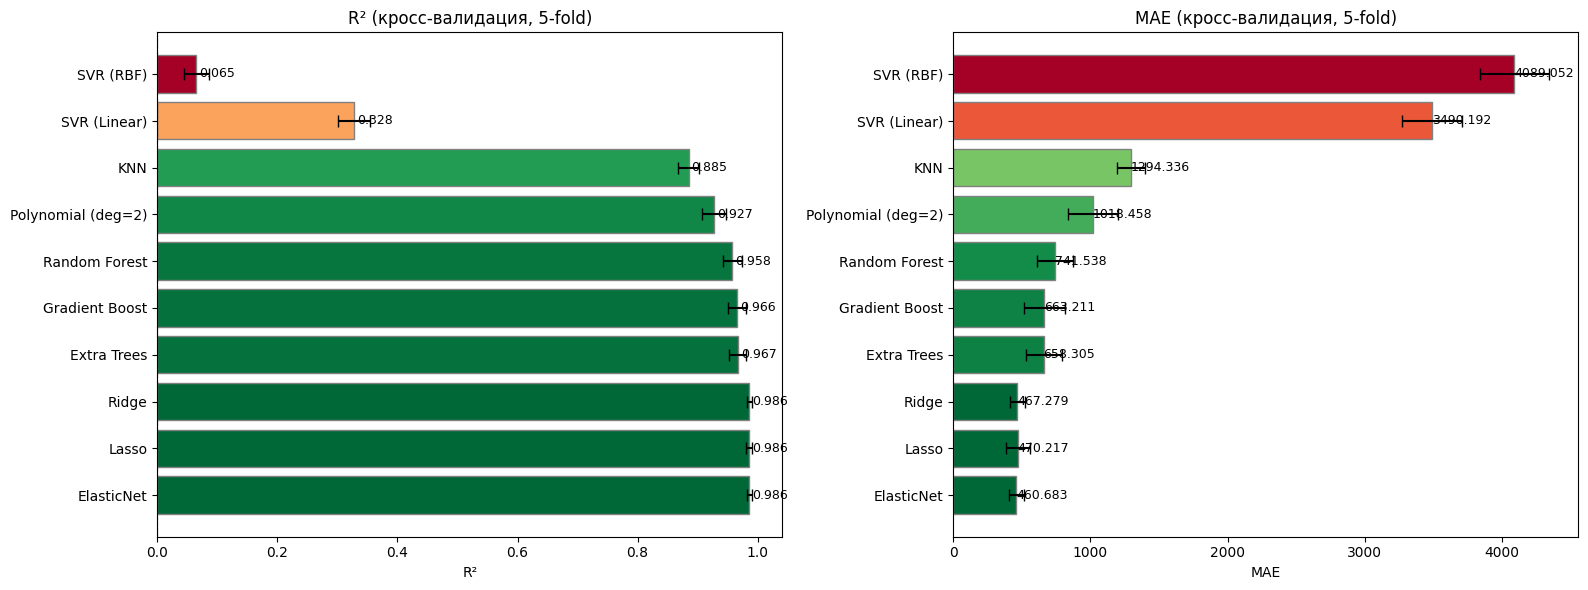

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = plt.cm.RdYlGn(
    (results_df['R² (mean)'] - results_df['R² (mean)'].min()) /
    (results_df['R² (mean)'].max() - results_df['R² (mean)'].min() + 1e-9)
)

# --- R² ---
bars = axes[0].barh(results_df['Модель'], results_df['R² (mean)'],
                    xerr=results_df['R² (std)'], color=colors,
                    edgecolor='grey', capsize=4)
axes[0].set_xlabel('R²')
axes[0].set_title('R² (кросс-валидация, 5-fold)')
axes[0].axvline(0, color='black', linewidth=0.8, linestyle='--')
for bar, val in zip(bars, results_df['R² (mean)']):
    axes[0].text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=9)

# --- MAE ---
colors_mae = plt.cm.RdYlGn(
    1 - (results_df['MAE (mean)'] - results_df['MAE (mean)'].min()) /
    (results_df['MAE (mean)'].max() - results_df['MAE (mean)'].min() + 1e-9)
)
bars2 = axes[1].barh(results_df['Модель'], results_df['MAE (mean)'],
                     xerr=results_df['MAE (std)'], color=colors_mae,
                     edgecolor='grey', capsize=4)
axes[1].set_xlabel('MAE')
axes[1].set_title('MAE (кросс-валидация, 5-fold)')
for bar, val in zip(bars2, results_df['MAE (mean)']):
    axes[1].text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('model_comparison_initial.png', dpi=150, bbox_inches='tight')
plt.show()

### Лучшая модель — оценка на тесте

In [42]:
best_name = results_df.iloc[0]['Модель']
best_model = models[best_name]

print(f'Лучшая модель: {best_name}')

best_model.fit(X_train_proc, y_train)

y_pred = best_model.predict(X_test_proc)

#y_pred = np.expm1(y_pred_log)

test_r2  = r2_score(y_test, y_pred)
test_mae = mean_absolute_error(y_test, y_pred)

print(f'Test R²  = {test_r2:.4f}')
print(f'Test MAE = {test_mae:.4f}')

Лучшая модель: ElasticNet
Test R²  = 0.9898
Test MAE = 458.9685


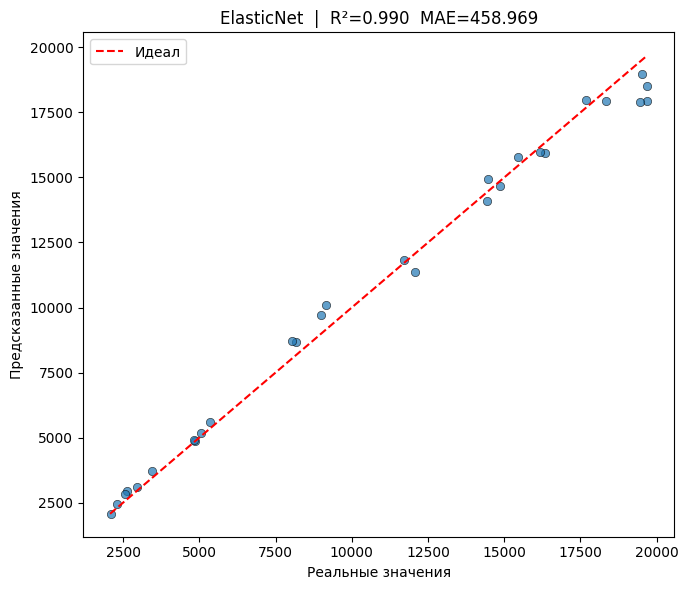

In [43]:
# Предсказанные vs Реальные
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.7, edgecolors='k', linewidths=0.5)
mn, mx = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
plt.plot([mn, mx], [mn, mx], 'r--', label='Идеал')
plt.xlabel('Реальные значения')
plt.ylabel('Предсказанные значения')
plt.title(f'{best_name}  |  R²={test_r2:.3f}  MAE={test_mae:.3f}')
plt.legend()
plt.tight_layout()
plt.savefig('predictions_vs_actual_initial.png', dpi=150, bbox_inches='tight')
plt.show()

### Важность признаков

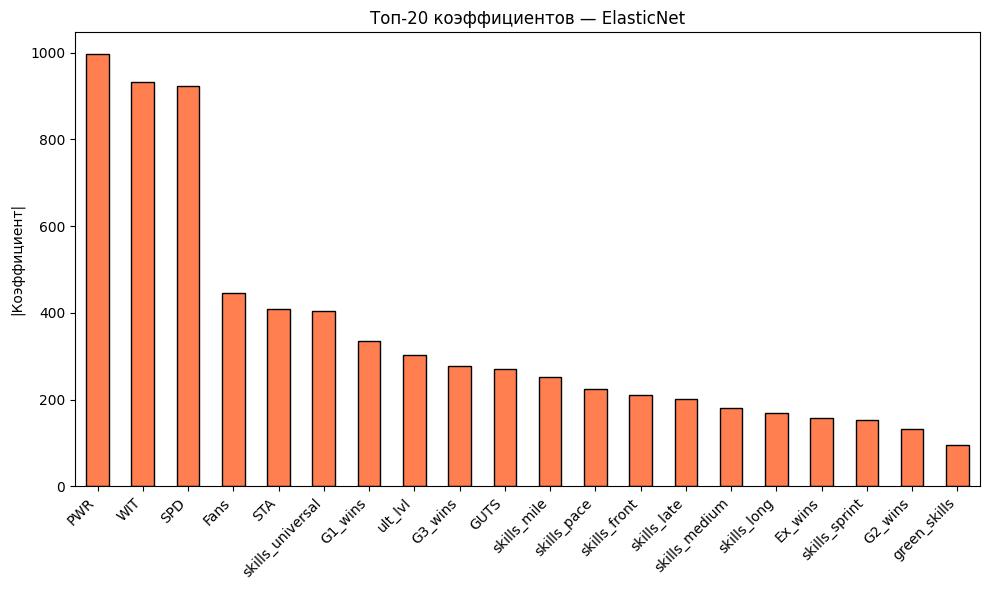

In [44]:
tree_models = {'Random Forest', 'Extra Trees', 'Gradient Boost'}

if best_name in tree_models:
    importances = pd.Series(best_model.feature_importances_,
                            index=X_train.columns).sort_values(ascending=False)
    plt.figure(figsize=(10, 6))
    importances.head(20).plot(kind='bar', color='steelblue', edgecolor='k')
    plt.title(f'Топ-20 важных признаков — {best_name}')
    plt.ylabel('Feature Importance')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('feature_importance_initial.png', dpi=150, bbox_inches='tight')
    plt.show()
elif best_name in {'Ridge', 'Lasso', 'ElasticNet', 'SVR (Linear)'}:
    if hasattr(best_model, 'coef_'):
        coefs = pd.Series(np.abs(best_model.coef_),
                          index=X_train.columns).sort_values(ascending=False)
        plt.figure(figsize=(10, 6))
        coefs.head(20).plot(kind='bar', color='coral', edgecolor='k')
        plt.title(f'Топ-20 коэффициентов — {best_name}')
        plt.ylabel('|Коэффициент|')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.savefig('feature_importance_initial.png', dpi=150, bbox_inches='tight')
        plt.show()
else:
    print(f'Для {best_name} importance недоступна напрямую.')